# Ali Ammar
## Roll no. KJPAPDA17936

In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
conn=sql.connect("chinook.db")
conn

In [3]:
def sql_query(q):
    return pd.read_sql_query(q,conn)

In [4]:
pd.read_sql_query("select * from sqlite_master",con=conn)

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [5]:
sql_query("select * from sqlite_master where type='table'")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


## Q1. Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)

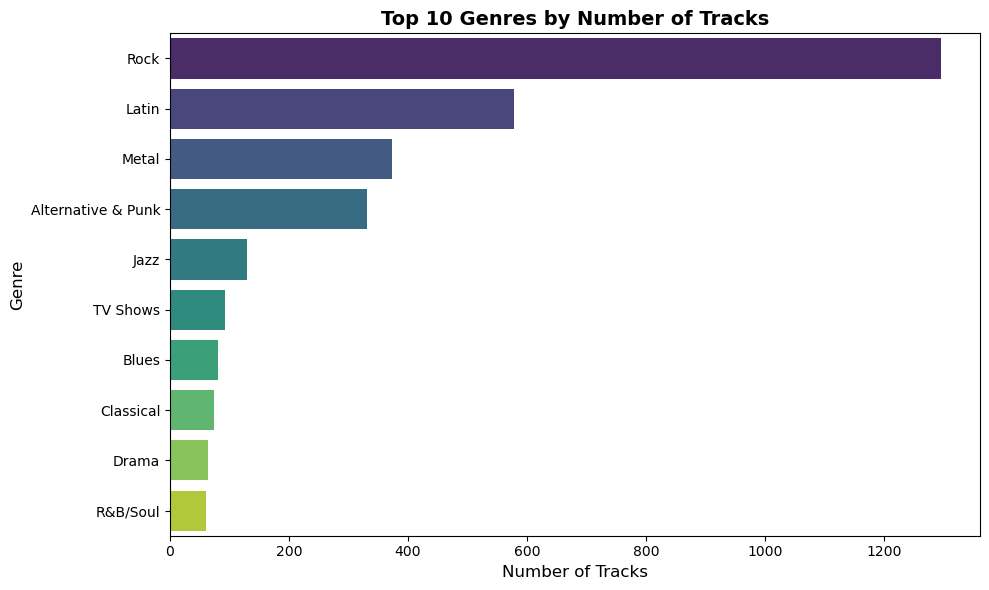

In [17]:
query='''
select g.name genre_name,count(t.track_id) track_count
from genre g
inner join track t
on g.genre_id = t.genre_id
group by g.genre_id, g.name
order by track_count DESC
limit 10
'''
df=sql_query(query)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df, 
    x='track_count', 
    y='genre_name', 
    palette='viridis'
)

plt.title('Top 10 Genres by Number of Tracks', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tracks', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()

plt.show()

## Q2. Write a query to list the top 10 albums that contain the most tracks.

In [18]:
query='''
select a.title album_title, count(t.track_id) total_tracks
from album a
inner join track t
on a.album_id = t.album_id
group by a.album_id, a.title
order by total_tracks desc
limit 10
'''
sql_query(query)

,album_title,total_tracks
0,Greatest Hits,57
1,Minha Historia,34
2,Unplugged,30
3,"Lost, Season 3",26
4,"Lost, Season 1",25
5,"The Office, Season 3",25
6,My Way: The Best Of Frank Sinatra [Disc 1],24
7,"Lost, Season 2",24
8,"Battlestar Galactica (Classic), Season 1",24
9,Afrociberdelia,23


## Q3. Write a query to find the top 10 customers who spent the most money.

In [19]:
query='''
select c.first_name || ' ' || c.last_name customer_name, sum(i.total) total_spent
from customer c
inner join invoice i
on c.customer_id = i.customer_id
group by c.customer_id, customer_name
order by total_spent desc
limit 10
'''
sql_query(query)

,customer_name,total_spent
0,František Wichterlová,144.54
1,Helena Holý,128.70
2,Hugh O'Reilly,114.84
3,Manoj Pareek,111.87
4,Luís Gonçalves,108.90
5,Fernanda Ramos,106.92
6,João Fernandes,102.96
7,François Tremblay,99.99
8,Wyatt Girard,99.99
9,Jack Smith,98.01


## Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [20]:
query='''
select ar.name artist_name, sum(il.unit_price * il.quantity) total_revenue
from artist ar
inner join album al
on ar.artist_id = al.artist_id
inner join track t
on al.album_id = t.album_id
inner join invoice_line il
on t.track_id = il.track_id
group by ar.artist_id, ar.name
order by total_revenue desc
limit 5
'''
sql_query(query)

,artist_name,total_revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Nirvana,128.70
3,Red Hot Chili Peppers,128.70
4,Pearl Jam,127.71


## Q5. Countries by Average Revenue per Invoice

In [21]:
query='''
select billing_country country, avg(total) avg_revenue
from invoice
group by billing_country
order by avg_revenue desc
'''
sql_query(query)

,country,avg_revenue
0,Czech Republic,9.108000
1,Spain,8.910000
2,Ireland,8.833846
3,United Kingdom,8.768571
4,India,8.721429
5,Belgium,8.627143
6,Germany,8.161463
7,Australia,8.118000
8,Norway,8.030000
9,USA,7.942672
